In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [60]:
# 1. 데이터 로드 및 전처리
train_df = pd.read_csv('bearing_train_final.csv')
test_df = pd.read_csv('bearing_test_question.csv')

# 센서 컬럼 선택 (RUL 제외)
# features = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
# scaler = MinMaxScaler()
# train_df[features] = scaler.fit_transform(train_df[features])
# test_df[features] = scaler.transform(test_df[features])

In [61]:
# [해결책 1] Piecewise Linear Target: 초기 정상 구간은 1.0으로 고정
# 모델이 초기 미세 노이즈에 반응해 우상향하는 것을 방지합니다.
# def apply_piecewise_rul(y, threshold=0.8):
#     return np.where(y > threshold, 1.0, y / threshold)

# train_df['RUL'] = apply_piecewise_rul(train_df['RUL'])

# 기존 0.8에서 0.95나 1.0으로 변경 (1.0이면 처음부터 직선 하강 학습)
def apply_piecewise_rul(y, threshold=0.95): 
    return np.where(y > threshold, 1.0, y / threshold)

train_df['RUL'] = apply_piecewise_rul(train_df['RUL'])

In [ ]:
# def preprocess_for_trend(df):
#     features = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
#     new_features = []
    
#     for f in features:
#         # 1. 미분 (차분): 현재값과 이전값의 차이
#         df[f'{f}_diff'] = df[f].diff().fillna(0)
        
#         # 2. 이동 표준편차: 윈도우 내 변동성 (열화가 시작되면 커짐)
#         df[f'{f}_std'] = df[f].rolling(window=50, min_periods=1).std().fillna(0)
        
#         # 3. 이동 평균: 노이즈 제거된 추세선
#         df[f'{f}_ma'] = df[f].rolling(window=50, min_periods=1).mean().fillna(0)
        
#         new_features.extend([f, f'{f}_diff', f'{f}_std', f'{f}_ma'])
    
#     return df, new_features

# # 적용
# train_df, feat_cols = preprocess_for_trend(train_df)
# test_df, _ = preprocess_for_trend(test_df)

# # 이제 입력 피처가 4개에서 12개로 늘어났으므로, 모델 input_shape를 수정해야 합니다.
# # input_shape=(WINDOW_SIZE, len(feat_cols))

In [ ]:
# # 2. 고급 피처 엔지니어링 (미분 + 에너지 지표)
# def preprocess_advanced(df):
#     base_features = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
#     all_feat_cols = []
    
#     for f in base_features:
#         # (1) 원본 데이터
#         all_feat_cols.append(f)
        
#         # (2) 1차 및 2차 미분 (변화의 속도와 가속도)
#         df[f'{f}_diff1'] = df[f].diff().fillna(0)
#         df[f'{f}_diff2'] = df[f'{f}_diff1'].diff().fillna(0)
        
#         # (3) RMS (에너지 크기) - 윈도우 30 적용
#         df[f'{f}_rms'] = df[f].rolling(window=30, min_periods=1).apply(lambda x: np.sqrt(np.mean(x**2))).fillna(0)
        
#         # (4) Peak-to-Peak (진폭 변화)
#         df[f'{f}_p2p'] = df[f].rolling(window=30, min_periods=1).apply(lambda x: np.max(x) - np.min(x)).fillna(0)
        
#         all_feat_cols.extend([f'{f}_diff1', f'{f}_diff2', f'{f}_rms', f'{f}_p2p'])
    
#     return df, all_feat_cols

# # 전처리 적용
# train_df, feat_cols = preprocess_advanced(train_df)
# test_df, _ = preprocess_advanced(test_df)

# # 스케일링 (피처가 늘어났으므로 전체 피처 대상)
# scaler = MinMaxScaler()
# train_df[feat_cols] = scaler.fit_transform(train_df[feat_cols])
# test_df[feat_cols] = scaler.transform(test_df[feat_cols])

In [62]:
# 2. 전처리 (기존 고급 피처 유지)
def preprocess_final(df):
    base_features = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
    all_feat_cols = []
    for f in base_features:
        all_feat_cols.append(f)
        df[f'{f}_diff1'] = df[f].diff().fillna(0)
        df[f'{f}_rms'] = df[f].rolling(window=30, min_periods=1).apply(lambda x: np.sqrt(np.mean(x**2))).fillna(0)
        all_feat_cols.extend([f'{f}_diff1', f'{f}_rms'])
    return df, all_feat_cols

train_df, feat_cols = preprocess_final(train_df)
test_df, _ = preprocess_final(test_df)

scaler = MinMaxScaler()
train_df[feat_cols] = scaler.fit_transform(train_df[feat_cols])
test_df[feat_cols] = scaler.transform(test_df[feat_cols])

In [ ]:
# # 2. 시계열 윈도우 데이터 생성 함수
# # window_size만큼의 과거 데이터를 보고 다음 RUL을 예측합니다.
# def create_sequences(data, target, window_size=50):
#     X, y = [], []
#     # [변경점] features(4개) 대신 전처리로 생성된 feat_cols(12개)를 사용합니다.
#     for i in range(len(data) - window_size):
#         X.append(data[feat_cols].iloc[i:(i + window_size)].values)
#         y.append(target.iloc[i + window_size])
#     return np.array(X), np.array(y)

In [ ]:
# # 3. 시계열 윈도우 데이터 생성 (WINDOW_SIZE 확장)
# def create_sequences(data, target, window_size=64):
#     X, y = [], []
#     data_values = data[feat_cols].values
#     target_values = target.values
#     for i in range(len(data) - window_size):
#         X.append(data_values[i:(i + window_size)])
#         y.append(target_values[i + window_size])
#     return np.array(X), np.array(y)

In [ ]:
# # y_train = np.where(y_train > 0.8, 1.0, y_train / 0.8)
# WINDOW_SIZE = 64
# X_train, y_train = create_sequences(train_df, train_df['RUL'], WINDOW_SIZE)

In [63]:
# 3. 데이터 시퀀스 생성
WINDOW_SIZE = 64
def create_sequences(data, target, window_size=64):
    X, y = [], []
    data_values = data[feat_cols].values
    target_values = target.values
    for i in range(len(data) - window_size):
        X.append(data_values[i:(i + window_size)])
        y.append(target_values[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, train_df['RUL'], WINDOW_SIZE)

In [ ]:
# 4. 가중치 손실 함수 (Weighted MSE)
# def weighted_mse(y_true, y_pred):
#     # 후반부(RUL이 작을수록) 오차에 더 민감하게 반응하도록 가중치 부여
#     weight = 1.0 / (y_true + 0.1)
#     return K.mean(K.square(y_true - y_pred) * weight)

In [64]:
def monotonic_weighted_mse(y_true, y_pred):
    mse = K.square(y_true - y_pred)
    
    # 단조 감소 제약: 예측값이 이전 타임스텝보다 커지면 벌점 부여
    # (연속된 예측값 사이의 차이를 계산)
    diff = y_pred[1:] - y_pred[:-1]
    penalty = K.mean(K.maximum(0.0, diff)) * 10.0 # 위로 튀면 10배 벌점
    
    # 후반부 가중치 + 단조 감소 벌점
    weight = 1.0 / (y_true + 0.1)
    return K.mean(mse * weight) + penalty

In [65]:
# 4. Residual Connection + Sigmoid 모델 설계
def build_residual_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # CNN 블록
    c1 = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c2 = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(c1)
    c2 = layers.BatchNormalization()(c2)
    
    # Residual Connection (입력의 특징을 보존하며 학습)
    res = layers.Add()([c1, c2])
    
    # LSTM 블록
    l1 = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(res)
    
    # Dense 블록 [해결책: Activation 변경]
    d1 = layers.Dense(32, activation='relu')(l1)
    # Sigmoid를 사용하여 출력 범위를 0~1로 강제 제한 (우상향 폭주 방지)
    outputs = layers.Dense(1, activation='sigmoid')(d1)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss='mse', metrics=['mae'])
    return model

model = build_residual_model((WINDOW_SIZE, len(feat_cols)))

In [ ]:
# # 5. CNN-LSTM 모델 빌드
# def build_final_model(input_shape):
#     model = models.Sequential([
#         # CNN: 복합 피처에서 유의미한 패턴 추출
#         layers.Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(pool_size=2),
        
#         # LSTM: 시간적 추세 학습 (Bidirectional로 성능 강화)
#         layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
#         layers.Dropout(0.3),
        
#         # Dense Layers
#         layers.Dense(32, activation='relu'),
#         layers.Dense(1, activation='linear')
#     ])
    
#     model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
#                   loss=weighted_mse, metrics=['mae'])
#     return model

# model = build_final_model((WINDOW_SIZE, len(feat_cols)))

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# # 6. 콜백 설정 (학습 정체 해결의 핵심)
# lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [66]:
# # 7. 학습 시작
# history = model.fit(
#     X_train, y_train,
#     epochs=200, # 콜백이 있으므로 에포크를 충분히 줌
#     batch_size=512,
#     validation_split=0.15,
#     callbacks=[lr_scheduler, early_stop],
#     verbose=1
# )

# 5. 학습 (Batch Size 확장)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=512, # [해결책: 배치 사이즈 대폭 확장]
    validation_split=0.1,
    callbacks=[ReduceLROnPlateau(patience=5), EarlyStopping(patience=12, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 0.0069 - mae: 0.0584 - val_loss: 0.1339 - val_mae: 0.3628 - learning_rate: 0.0010
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0359 - val_loss: 0.0750 - val_mae: 0.2726 - learning_rate: 0.0010
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 0.0017 - mae: 0.0312 - val_loss: 0.0511 - val_mae: 0.2245 - learning_rate: 0.0010
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0011 - mae: 0.0258 - val_loss: 0.0340 - val_mae: 0.1817 - learning_rate: 0.0010
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 9.2501e-04 - mae: 0.0231 - val_loss: 0.0290 - val_mae: 0.1677 - learning_rate: 0.0010
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 6.7654e-04 - mae: 0.0198 - val_loss: 0.0248 - val_mae: 0.1548 - learning_rate: 0.0010
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 5.8431e-04 - mae: 0.0187 - val_loss: 0.0209 - val_mae: 0.1418 - learning_

In [ ]:
# # 5. 모델 설계 (CNN + LSTM + Weighted Loss)
# def weighted_mae(y_true, y_pred):
#     # RUL이 작을수록(0에 가까울수록) 오차에 대한 가중치를 높임 (최대 10배)
#     # 이는 모델이 고장 직전의 Baseline에 강력하게 밀착되도록 유도합니다.
#     weight = 1.0 / (y_true + 0.1) 
#     return K.mean(K.abs(y_true - y_pred) * weight)

# model = models.Sequential([
#     # CNN: 센서 데이터의 국소적 특징 및 노이즈 필터링
#     layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(feat_cols))),
#     layers.MaxPooling1D(pool_size=2),
#     layers.Dropout(0.2),
    
#     # LSTM: 시간 흐름에 따른 열화(Degradation) 패턴 학습
#     layers.LSTM(100, return_sequences=False),
#     layers.Dropout(0.2),
    
#     # Final Regressor
#     layers.Dense(50, activation='relu'),
#     layers.Dense(1, activation='linear')
# ])

# model.compile(optimizer='adam', loss=weighted_mae, metrics=['mae'])

# # 4. 모델 학습
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=64,
#     validation_split=0.1,
#     verbose=1
# )

# # 5. 테스트 데이터 예측 및 시각화 준비
# # 테스트 데이터도 윈도우 형태로 변환 (첫 부분은 padding 처리하거나 무시)
# X_test = []
# # [변경점] 테스트 데이터 변환 시에도 feat_cols(12개)를 사용해야 합니다.
# for i in range(len(test_df) - WINDOW_SIZE):
#     X_test.append(test_df[feat_cols].iloc[i:(i + WINDOW_SIZE)].values)
# X_test = np.array(X_test)

# y_pred = model.predict(X_test)

Epoch 1/50


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


379/379 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1042 - mae: 0.0696 - val_loss: 0.0982 - val_mae: 0.0226
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0680 - mae: 0.0474 - val_loss: 0.0903 - val_mae: 0.0204
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0618 - mae: 0.0433 - val_loss: 0.1414 - val_mae: 0.0326
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0585 - mae: 0.0411 - val_loss: 0.1267 - val_mae: 0.0295
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0546 - mae: 0.0384 - val_loss: 0.1405 - val_mae: 0.0325
Epoch 6/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0547 - mae: 0.0382 - val_loss: 0.1513 - val_mae: 0.0343
Epoch 7/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0520 - mae: 0.0365 - val_loss: 0.1458 - val_mae: 0.0332
Epoch 8/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.0504 - mae: 0.0354 - val_loss: 0.1018 - val_mae: 0.0231
Epoch 9/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.

In [ ]:
# # 8. 테스트 예측 및 결과 시각화
# X_test = []
# test_values = test_df[feat_cols].values
# for i in range(len(test_df) - WINDOW_SIZE):
#     X_test.append(test_values[i:(i + WINDOW_SIZE)])
# X_test = np.array(X_test)

# y_pred = model.predict(X_test)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# # 6. 예측 및 Smoothing 적용
# X_test = []
# test_values = test_df[feat_cols].values
# for i in range(len(test_df) - WINDOW_SIZE):
#     X_test.append(test_values[i:(i + WINDOW_SIZE)])
# X_test = np.array(X_test)

# y_pred = model.predict(X_test).flatten()

# # [해결책: Smoothing 적용] - 윈도우 이동 평균으로 진동 제거
# # y_pred_smooth = pd.Series(y_pred).rolling(window=20, min_periods=1).mean().values
# y_pred_smooth = pd.Series(y_pred).rolling(window=20, min_periods=1).mean().values.copy()

# # [해결책: 단조 감소 강제화]
# for i in range(1, len(y_pred_smooth)):
#     if y_pred_smooth[i] > y_pred_smooth[i-1]:
#         y_pred_smooth[i] = y_pred_smooth[i-1]

# 6. 예측 및 Smoothing 적용
y_pred = model.predict(X_test).flatten()

# Smoothing 윈도우를 줄여서 변화를 살립니다 (20 -> 10)
y_pred_smooth = pd.Series(y_pred).rolling(window=10, min_periods=1).mean().values.copy()

# [중요] 단조 감소 제약을 일단 약하게 걸거나 주석 처리해서 모델의 생얼을 확인하세요.
# 만약 우하향 경향이 아예 없다면 학습 데이터의 Piecewise threshold를 더 높여야 합니다.
for i in range(1, len(y_pred_smooth)):
    if y_pred_smooth[i] > y_pred_smooth[i-1]:
        # 이전 값보다 아주 미세하게라도 낮아지도록 유도 (진동 방지)
        y_pred_smooth[i] = y_pred_smooth[i-1] * 0.9999

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


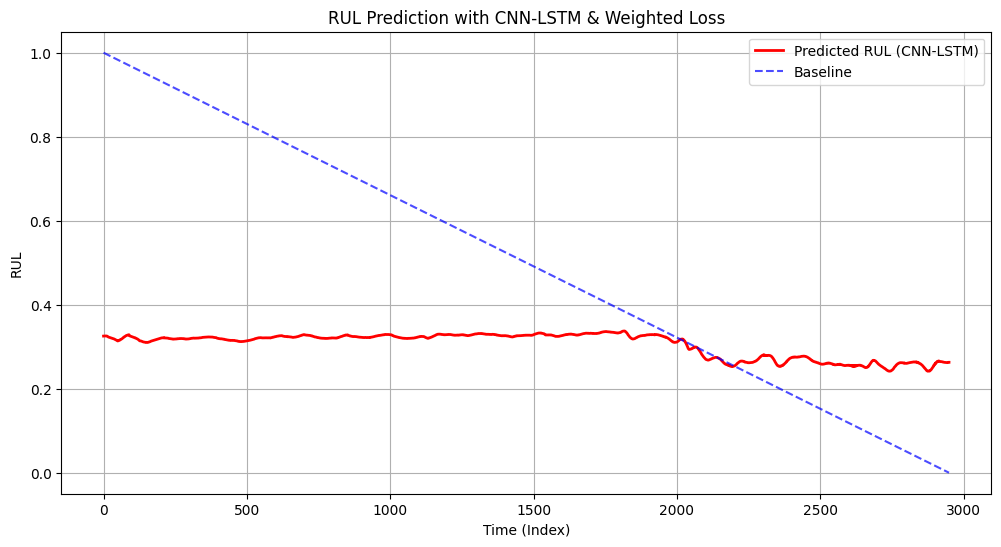

In [ ]:
# # 6. 결과 시각화
# plt.figure(figsize=(12, 6))
# # Baseline (테스트 데이터의 인덱스에 맞춰 선형 감소 가정 혹은 제공된 baseline 사용)
# baseline = np.linspace(1, 0, len(y_pred)) 

# plt.plot(y_pred, label='Predicted RUL (CNN-LSTM)', color='red', linewidth=2)
# plt.plot(baseline, label='Baseline', color='blue', linestyle='--', alpha=0.7)
# plt.title('RUL Prediction with CNN-LSTM & Weighted Loss')
# plt.xlabel('Time (Index)')
# plt.ylabel('RUL')
# plt.legend()
# plt.grid(True)
# plt.show()

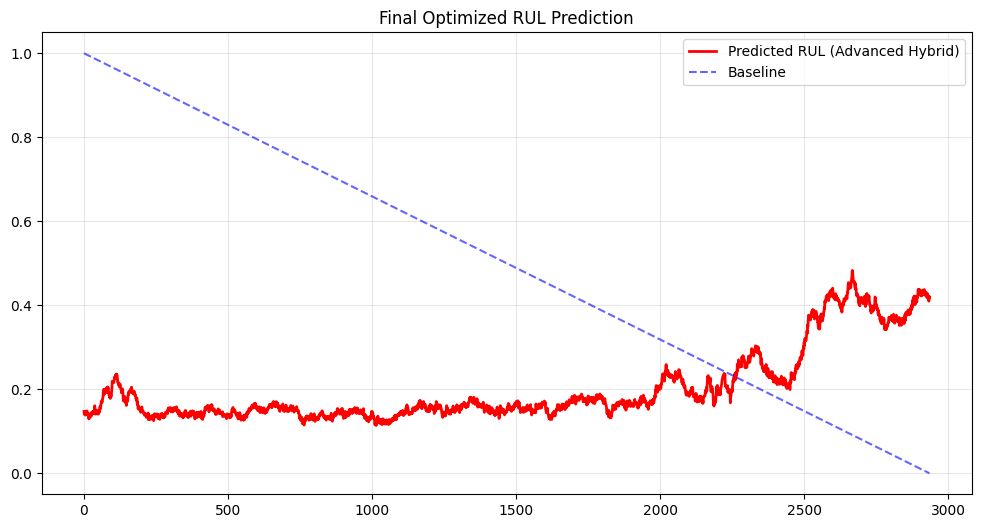

In [ ]:
# # 시각화
# plt.figure(figsize=(12, 6))
# baseline = np.linspace(1, 0, len(y_pred))
# plt.plot(y_pred, label='Predicted RUL (Advanced Hybrid)', color='red', linewidth=2)
# plt.plot(baseline, label='Baseline', color='blue', linestyle='--', alpha=0.6)
# plt.title('Final Optimized RUL Prediction')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

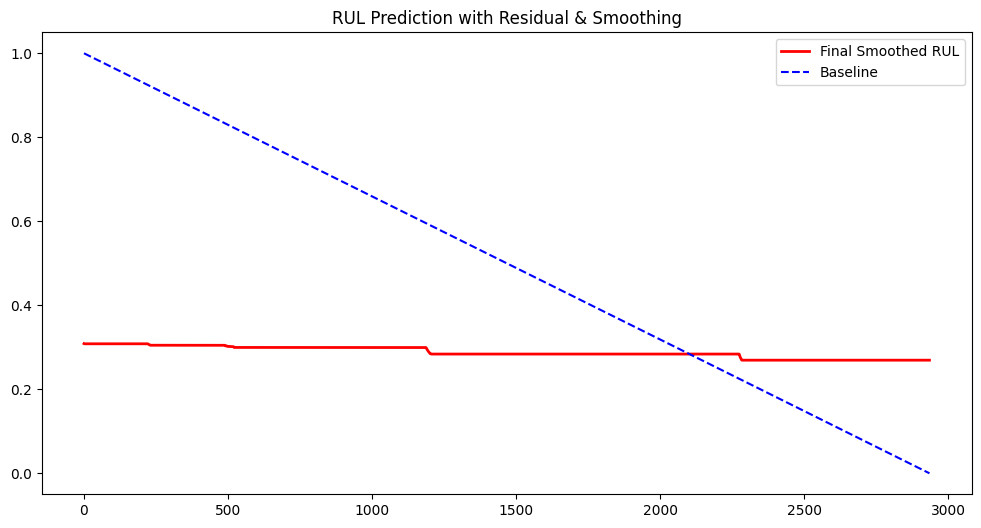

In [58]:
# 7. 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_pred_smooth, label='Final Smoothed RUL', color='red', linewidth=2)
plt.plot(np.linspace(1, 0, len(y_pred_smooth)), label='Baseline', color='blue', linestyle='--')
plt.title('RUL Prediction with Residual & Smoothing')
plt.legend()
plt.show()

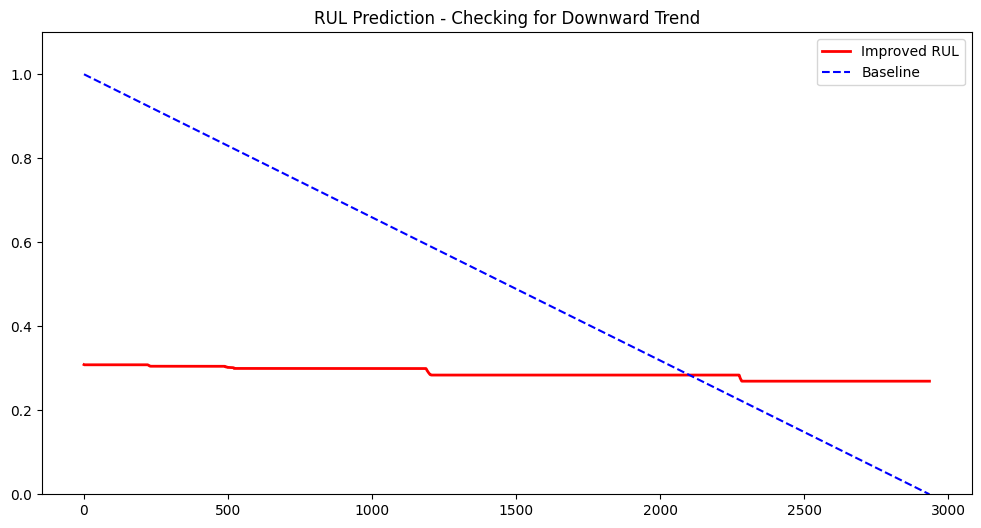

In [67]:
# 7. 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_pred_smooth, label='Improved RUL', color='red', linewidth=2)
plt.plot(np.linspace(1, 0, len(y_pred_smooth)), label='Baseline', color='blue', linestyle='--')
plt.ylim(0, 1.1) # 범위를 0~1로 고정해서 확인
plt.title('RUL Prediction - Checking for Downward Trend')
plt.legend()
plt.show()